In [24]:
import os
import pandas as pd


best_objectives_dir = '../best_solutions/'

best_objectives = pd.read_csv(os.path.join(best_objectives_dir, 'best_objectives.csv'))


In [25]:
from pathlib import Path
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# --- Configuration ---
results_folder = Path("../results")
instance_param = "instance_0001.txt"  # For per-instance detail views

# --- Auto-discover result folders and load all summary CSVs ---
run_dirs = sorted([d for d in results_folder.iterdir() if d.is_dir()])
if not run_dirs:
    raise FileNotFoundError(f"No result folders found in {results_folder.resolve()}")

print(f"Found {len(run_dirs)} result folder(s): {[d.name for d in run_dirs]}")

# Load and concatenate all summary CSVs
summary_frames = []
for run_dir in run_dirs:
    for csv_path in run_dir.glob("summary_*.csv"):
        frame = pd.read_csv(csv_path)
        frame["run_id"] = run_dir.name
        summary_frames.append(frame)

if not summary_frames:
    raise FileNotFoundError("No summary CSVs found in any result folder")

df = pd.concat(summary_frames, ignore_index=True)
df["instance_num"] = df["instance"].str.extract(r"(\d+)").astype(int)
df = df.sort_values(["instance_num", "algorithm"]).reset_index(drop=True)

print(f"Loaded {len(df)} rows, {df['algorithm'].nunique()} algorithms, {df['instance'].nunique()} instances")
print(f"Algorithms: {sorted(df['algorithm'].unique())}")
df.head()

Found 1 result folder(s): ['a_20260331_215337']
Loaded 88 rows, 6 algorithms, 20 instances
Algorithms: ['aisle_cluster_expansion', 'greedy_set_cover', 'lagrangian_relaxation', 'lp_aisle_focus', 'simple', 'simple_multi']


,dataset,algorithm,instance,total_runs,feasible_runs,timed_out_runs,objective_mean,objective_median,objective_mode,objective_min,...,aisles_std_dev,exec_time_mean,exec_time_median,exec_time_mode,exec_time_min,exec_time_max,exec_time_variance,exec_time_std_dev,run_id,instance_num
0,a,aisle_cluster_expansion,instance_0001.txt,5,5,0,15.000000,15.000000,15.000000,15.000000,...,0.000000,0.124405,0.123512,0.108889,0.108889,0.143038,1.355987e-04,0.011645,a_20260331_215337,1
1,a,greedy_set_cover,instance_0001.txt,5,5,0,11.333333,11.333333,11.333333,11.333333,...,0.000000,0.705533,0.770570,0.786424,0.401327,0.798970,2.324980e-02,0.152479,a_20260331_215337,1
2,a,lagrangian_relaxation,instance_0001.txt,5,5,0,15.000000,15.000000,15.000000,15.000000,...,0.000000,0.656804,0.665462,0.597806,0.597806,0.702892,1.205530e-03,0.034721,a_20260331_215337,1
3,a,lp_aisle_focus,instance_0001.txt,5,5,0,12.000000,12.000000,12.000000,12.000000,...,0.000000,0.496720,0.491798,0.345070,0.323905,0.679118,2.155241e-02,0.146807,a_20260331_215337,1
4,a,simple,instance_0001.txt,5,5,0,2.818971,2.833333,2.833333,2.680000,...,0.632456,0.002683,0.002765,0.002404,0.002130,0.003113,1.352794e-07,0.000368,a_20260331_215337,1


## Feasibility & Timeout Summary

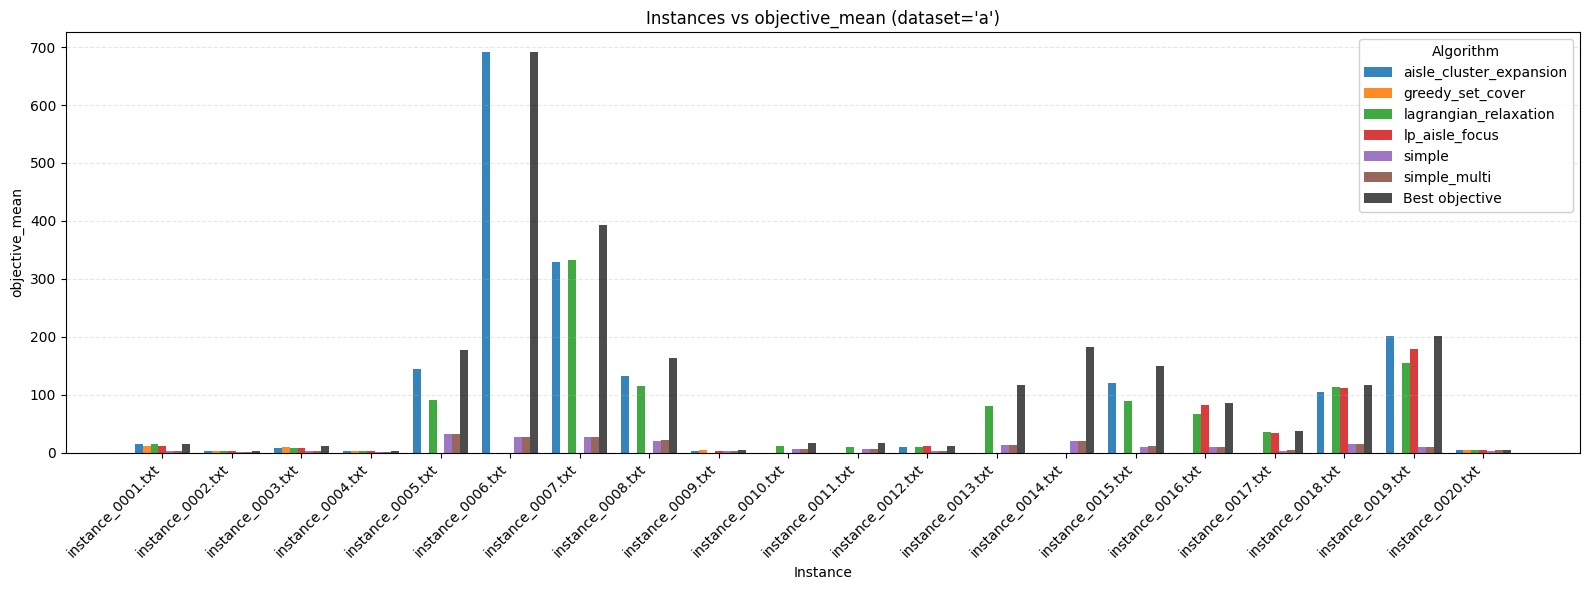

In [26]:
dataset_param = "a"

# Filter by dataset
plot_df = df.copy()
if dataset_param is not None:
    plot_df = plot_df[plot_df["dataset"] == dataset_param]

if plot_df.empty:
    raise ValueError(f"No rows found for dataset={dataset_param!r}")

plot_df["instance_order"] = (
    plot_df["instance"].astype(str).str.extract(r"(\d+)").fillna("-1").astype(int)
)

plot_df = plot_df.sort_values(["instance_order", "instance", "algorithm"]).reset_index(drop=True)

ordered_instances = (
    plot_df[["instance_order", "instance"]]
    .drop_duplicates()
    .sort_values(["instance_order", "instance"])["instance"]
    .tolist()
)

instance_to_x = {name: idx for idx, name in enumerate(ordered_instances)}

plot_df["instance_x"] = plot_df["instance"].map(instance_to_x)

algorithms = sorted(plot_df["algorithm"].unique())
n_algos = len(algorithms)
n_series = n_algos + 1  # +1 for Best objective bar at the last position
bar_width = 0.8 / n_series if n_series > 0 else 0.8
offsets = np.linspace(-0.4 + bar_width / 2, 0.4 - bar_width / 2, n_series) if n_series > 1 else np.array([0.0])

fig, ax = plt.subplots(figsize=(16, 6))
for idx, algo in enumerate(algorithms):
    group = plot_df[plot_df["algorithm"] == algo].sort_values("instance_order").copy()
    group["plot_x"] = group["instance_x"] + offsets[idx]
    ax.bar(group["plot_x"], group["objective_mean"], width=bar_width, alpha=0.9, label=algo)

filtered_df = best_objectives[best_objectives["dataset"] == dataset_param].copy()

if not filtered_df.empty:
    filtered_df["instance_order"] = (
        filtered_df["instance"].astype(str).str.extract(r"(\d+)").fillna("-1").astype(int)
    )
    filtered_df["instance_x"] = filtered_df["instance"].map(instance_to_x)
    filtered_df = filtered_df.dropna(subset=["instance_x"]).copy()
    filtered_df["plot_x"] = filtered_df["instance_x"] + offsets[-1]
    ax.bar(
        filtered_df["plot_x"],
        filtered_df["best_objective"],
        width=bar_width,
        color="black",
        alpha=0.7,
        label="Best objective",
        zorder=5,
    )

ax.set_title(f"Instances vs objective_mean (dataset={dataset_param!r})")
ax.set_xlabel("Instance")
ax.set_ylabel("objective_mean")
ax.set_xticks(range(len(ordered_instances)))
ax.set_xticklabels(ordered_instances, rotation=45, ha="right")
ax.grid(True, linestyle="--", alpha=0.3, axis="y")
ax.legend(title="Algorithm", loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.show()

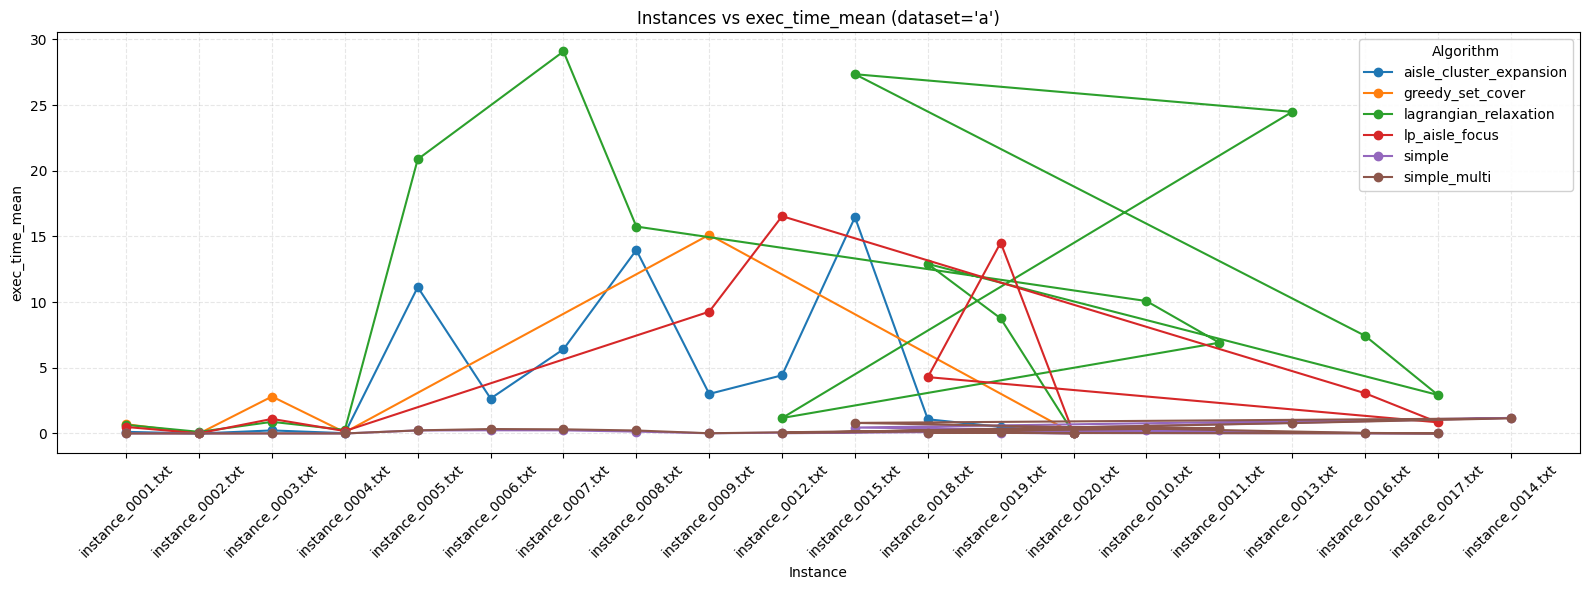

In [27]:
dataset_plot_param = "a"

time_df = df.copy()
if dataset_plot_param is not None:
    time_df = time_df[time_df["dataset"] == dataset_plot_param]

if time_df.empty:
    raise ValueError(f"No rows found for dataset={dataset_plot_param!r}")

time_df["instance_order"] = (
    time_df["instance"].astype(str).str.extract(r"(\d+)").fillna("-1").astype(int)
)
time_df = time_df.sort_values(["instance_order", "instance", "algorithm"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 6))
for algo, group in time_df.groupby("algorithm", sort=True):
    line_data = group.sort_values("instance_order")
    ax.plot(line_data["instance"], line_data["exec_time_mean"], marker="o", linewidth=1.5, label=algo)

ax.set_title(f"Instances vs exec_time_mean (dataset={dataset_plot_param!r})")
ax.set_xlabel("Instance")
ax.set_ylabel("exec_time_mean")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(title="Algorithm", loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.show()

In [28]:
ranking_dataset_param = "a"

ranking_base = df[["dataset", "instance", "algorithm", "objective_mean", "exec_time_mean"]].copy()
if ranking_dataset_param is not None:
    ranking_base = ranking_base[ranking_base["dataset"] == ranking_dataset_param]

if ranking_base.empty:
    raise ValueError(f"No rows found for dataset={ranking_dataset_param!r}")

def build_ranking(
    base_df: pd.DataFrame,
    metric_column: str,
    ascending: bool,
    score_column: str,
    class_column: str,
 ) -> tuple[pd.DataFrame, pd.DataFrame]:
    ranking_by_instance = base_df.dropna(subset=[metric_column]).copy()
    if ranking_by_instance.empty:
        raise ValueError(f"No non-null values found for metric {metric_column!r}.")

    ranking_by_instance["N"] = ranking_by_instance.groupby(["dataset", "instance"])[
        "algorithm"
    ].transform("nunique")
    ranking_by_instance[class_column] = ranking_by_instance.groupby(["dataset", "instance"])[
        metric_column
    ].rank(method="min", ascending=ascending).astype(int)
    ranking_by_instance[score_column] = (
        ranking_by_instance["N"] - ranking_by_instance[class_column]
    )

    score_table = (
        ranking_by_instance.groupby("algorithm", as_index=False)[score_column]
        .agg(total_score="sum", average_score="mean", instances_count="count")
        .sort_values(["total_score", "average_score", "algorithm"], ascending=[False, False, True])
        .reset_index(drop=True)
    )
    score_table["final_rank"] = score_table["total_score"].rank(
        method="min", ascending=False
    ).astype(int)
    score_table = score_table[[
        "final_rank",
        "algorithm",
        "total_score",
        "average_score",
        "instances_count",
    ]]

    return ranking_by_instance.sort_values(["dataset", "instance", class_column, "algorithm"]), score_table

objective_instance_scores, objective_ranking = build_ranking(
    ranking_base,
    metric_column="objective_mean",
    ascending=False,
    score_column="objective_score",
    class_column="objective_class",
)

exec_time_instance_scores, exec_time_ranking = build_ranking(
    ranking_base,
    metric_column="exec_time_mean",
    ascending=True,
    score_column="exec_time_score",
    class_column="exec_time_class",
)

print(f"Dataset filter for ranking: {ranking_dataset_param!r}")

print("\nOBJECTIVE_MEAN - SCORE BY INSTANCE")
display(
    objective_instance_scores[[
        "dataset",
        "instance",
        "algorithm",
        "objective_mean",
        "N",
        "objective_class",
        "objective_score",
    ]]
)

print("\nOBJECTIVE_MEAN - FINAL RANKING")
display(objective_ranking)

print("\nEXEC_TIME_MEAN - SCORE BY INSTANCE")
display(
    exec_time_instance_scores[[
        "dataset",
        "instance",
        "algorithm",
        "exec_time_mean",
        "N",
        "exec_time_class",
        "exec_time_score",
    ]]
)

print("\nEXEC_TIME_MEAN - FINAL RANKING")
display(exec_time_ranking)

Dataset filter for ranking: 'a'

OBJECTIVE_MEAN - SCORE BY INSTANCE


,dataset,instance,algorithm,objective_mean,N,objective_class,objective_score
0,a,instance_0001.txt,aisle_cluster_expansion,15.000000,6,1,5
2,a,instance_0001.txt,lagrangian_relaxation,15.000000,6,1,5
3,a,instance_0001.txt,lp_aisle_focus,12.000000,6,3,3
1,a,instance_0001.txt,greedy_set_cover,11.333333,6,4,2
5,a,instance_0001.txt,simple_multi,3.246934,6,5,1
...,...,...,...,...,...,...,...
83,a,instance_0020.txt,greedy_set_cover,5.000000,6,1,5
84,a,instance_0020.txt,lagrangian_relaxation,5.000000,6,1,5
85,a,instance_0020.txt,lp_aisle_focus,5.000000,6,1,5
87,a,instance_0020.txt,simple_multi,4.733333,6,5,1



OBJECTIVE_MEAN - FINAL RANKING


,final_rank,algorithm,total_score,average_score,instances_count
0,1,lagrangian_relaxation,52,3.058824,17
1,2,aisle_cluster_expansion,49,3.500000,14
2,3,lp_aisle_focus,37,3.363636,11
3,4,greedy_set_cover,26,4.333333,6
4,5,simple_multi,20,1.000000,20
5,6,simple,1,0.050000,20



EXEC_TIME_MEAN - SCORE BY INSTANCE


,dataset,instance,algorithm,exec_time_mean,N,exec_time_class,exec_time_score
4,a,instance_0001.txt,simple,0.002683,6,1,5
5,a,instance_0001.txt,simple_multi,0.003024,6,2,4
0,a,instance_0001.txt,aisle_cluster_expansion,0.124405,6,3,3
3,a,instance_0001.txt,lp_aisle_focus,0.496720,6,4,2
2,a,instance_0001.txt,lagrangian_relaxation,0.656804,6,5,1
...,...,...,...,...,...,...,...
87,a,instance_0020.txt,simple_multi,0.000132,6,2,4
82,a,instance_0020.txt,aisle_cluster_expansion,0.000304,6,3,3
83,a,instance_0020.txt,greedy_set_cover,0.000323,6,4,2
85,a,instance_0020.txt,lp_aisle_focus,0.002346,6,5,1



EXEC_TIME_MEAN - FINAL RANKING


,final_rank,algorithm,total_score,average_score,instances_count
0,1,simple,65,3.250000,20
1,2,simple_multi,51,2.550000,20
2,3,aisle_cluster_expansion,25,1.785714,14
3,4,lp_aisle_focus,10,0.909091,11
4,5,greedy_set_cover,7,1.166667,6
5,6,lagrangian_relaxation,6,0.352941,17
